In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data   # provides sample images (camera, checkerboard, coins, ...)

# Make plots show inside the notebook
%matplotlib inline



###Task 1 — Canny Edge Detection

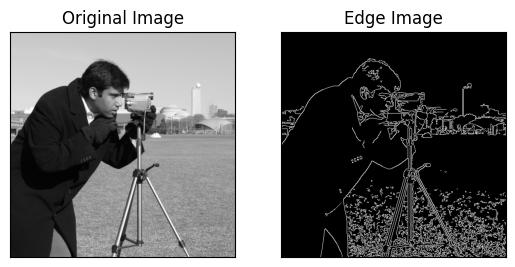

In [2]:
img = data.camera()

edges = cv2.Canny(img, 100, 200)

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

###Task 2 — Harris Corner Detection

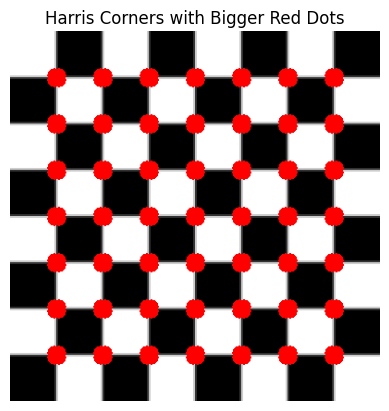

In [3]:
board = data.checkerboard()
image = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR)
image = cv2.resize(image, (400, 400), interpolation=cv2.INTER_NEAREST)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

# Harris Corner Detection
harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Threshold for detecting strong corners
threshold = 0.01 * harris.max()
corner_coords = np.argwhere(harris > threshold)

# Draw larger red dots (radius = 7)
for y, x in corner_coords:
    cv2.circle(image, (x, y), radius=7, color=(0, 0, 255), thickness=-1)  # -1 = filled

# Display
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners with Bigger Red Dots')
plt.axis('off')
plt.show()

###Q1 — Otsu's Thresholding (Assessment Task)

Otsu threshold T = 104.0


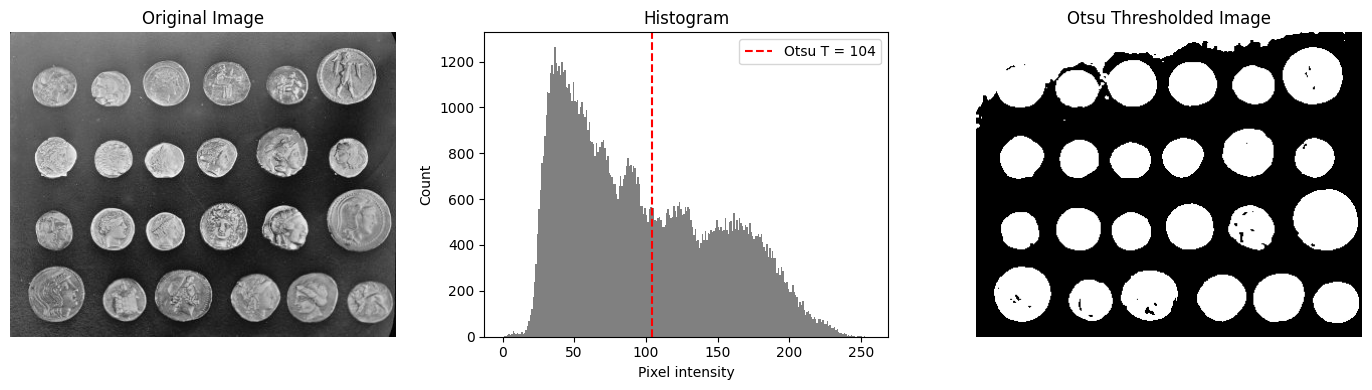

In [4]:
img = data.coins()
blur = cv2.GaussianBlur(img, (5, 5), 0)
T, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print("Otsu threshold T =", T)

plt.figure(figsize=(14, 4))

plt.subplot(131)
plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.axis('off')

plt.subplot(132)
plt.hist(img.ravel(), bins=256, range=(0, 256), color='gray')
plt.axvline(T, color='red', linestyle='--', label=f'Otsu T = {T:.0f}')
plt.title('Histogram'), plt.xlabel('Pixel intensity'), plt.ylabel('Count')
plt.legend()

plt.subplot(133)
plt.imshow(binary, cmap='gray')
plt.title('Otsu Thresholded Image'), plt.axis('off')

plt.tight_layout()
plt.show()